# Machine Exercise 1 — 3-Layer CNN for MNIST with **einops / einsum**

A 3-convolution-layer CNN for MNIST digit classification in which **every layer and
tensor operation is implemented with `einops` / `torch.einsum`** (no `nn.Conv2d`,
`nn.MaxPool2d`, `nn.Linear`, or `.view()` in the model):

| Operation        | Standard PyTorch | This notebook |
|------------------|------------------|---------------|
| Conv2d           | `F.conv2d`       | `Tensor.unfold` (im2col) → `einops.rearrange` → `torch.einsum` |
| MaxPool2d (2×2)  | `F.max_pool2d`   | `einops.reduce(..., 'max')` |
| Flatten          | `x.view(-1)`     | `einops.rearrange('b c h w -> b (c h w)')` |
| Linear (FC)      | `F.linear`       | `torch.einsum('bn,ne->be')` |

**Architecture** (input `b, 1, 28, 28`):

```
Conv2d(1→32, 3×3, pad 1) → ReLU → MaxPool2 → (b, 32, 14, 14)
Conv2d(32→64, 3×3, pad 1) → ReLU → MaxPool2 → (b, 64, 7, 7)
Conv2d(64→128, 3×3, pad 1) → ReLU → Flatten → (b, 6272)
Linear(6272→10) → logits
```


## 1. Imports & setup

In [1]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import einops
from einops import rearrange, reduce
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
torch.set_num_threads(16)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| einops", einops.__version__)
print("device:", device)

torch 2.13.0+cu130 | einops 0.8.2
device: cuda


## 2. Data — MNIST (60k train / 10k test)

In [2]:
MEAN, STD = 0.1307, 0.3081  # standard MNIST statistics
tfm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((MEAN,), (STD,)),
])
train_ds = datasets.MNIST("./data", train=True,  download=True, transform=tfm)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=tfm)

BATCH = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)
print(f"train: {len(train_ds)}  test: {len(test_ds)}")

train: 60000  test: 10000


## 3. Layers built with einops / einsum

* **`EinopsConv2d`** — extracts sliding windows with `Tensor.unfold` (a pure view,
  i.e. im2col), packs them with `einops.rearrange`, and does the whole convolution
  as one `torch.einsum('bnc,oc->bno', patches, weight)`.
* **`EinopsMaxPool2d`** — 2×2 max pooling is literally
  `einops.reduce(x, 'b c (h 2) (w 2) -> b c h w', 'max')`.
* **`EinopsLinear`** — `torch.einsum('bn,ne->be', x, W) + b`.

In [3]:
class EinopsConv2d(nn.Module):
    """Conv2d = im2col (unfold view) + einops.rearrange + torch.einsum."""
    def __init__(self, cin, cout, k, stride=1, padding=0):
        super().__init__()
        self.k, self.stride, self.padding = k, stride, padding
        self.weight = nn.Parameter(torch.empty(cout, cin, k, k))
        self.bias   = nn.Parameter(torch.empty(cout))
        nn.init.kaiming_uniform_(self.weight, a=5 ** 0.5)
        nn.init.zeros_(self.bias)

    def forward(self, x):  # x: (b, cin, h, w)
        if self.padding:
            x = F.pad(x, (self.padding,) * 4)
        H, W = x.shape[-2:]
        h_out = (H - self.k) // self.stride + 1
        w_out = (W - self.k) // self.stride + 1
        # sliding windows -> (b, cin, h_out, w_out, k, k)
        p = x.unfold(2, self.k, self.stride).unfold(3, self.k, self.stride)
        # pack patches and weights -> (b, h_out*w_out, cin*k*k) / (cout, cin*k*k)
        p = rearrange(p, 'b c h w kh kw -> b (h w) (c kh kw)')
        w = rearrange(self.weight, 'o i kh kw -> o (i kh kw)')
        out = torch.einsum('bnc,oc->bno', p, w) + self.bias
        return rearrange(out, 'b (h w) o -> b o h w', h=h_out, w=w_out)


class EinopsMaxPool2d(nn.Module):
    """MaxPool via einops.reduce."""
    def __init__(self, kernel=2):
        super().__init__()
        self.k = kernel

    def forward(self, x):  # (b, c, h, w)
        return reduce(x, 'b c (h p1) (w p2) -> b c h w', 'max', p1=self.k, p2=self.k)


class EinopsLinear(nn.Module):
    """Fully-connected layer via torch.einsum."""
    def __init__(self, in_f, out_f):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_f, out_f))
        self.bias   = nn.Parameter(torch.empty(out_f))
        nn.init.kaiming_uniform_(self.weight)
        nn.init.zeros_(self.bias)

    def forward(self, x):  # (b, n)
        return torch.einsum('bn,ne->be', x, self.weight) + self.bias


class EinopsCNN(nn.Module):
    """3 conv layers + 2 max pools + 1 linear — all einops/einsum."""
    def __init__(self):
        super().__init__()
        self.conv1 = EinopsConv2d(1, 32, 3, padding=1)
        self.pool1 = EinopsMaxPool2d(2)
        self.conv2 = EinopsConv2d(32, 64, 3, padding=1)
        self.pool2 = EinopsMaxPool2d(2)
        self.conv3 = EinopsConv2d(64, 128, 3, padding=1)
        self.fc    = EinopsLinear(128 * 7 * 7, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))                # (b, 32, 28, 28)
        x = self.pool1(x)                            # (b, 32, 14, 14)
        x = torch.relu(self.conv2(x))                # (b, 64, 14, 14)
        x = self.pool2(x)                            # (b, 64, 7, 7)
        x = torch.relu(self.conv3(x))                # (b, 128, 7, 7)
        x = rearrange(x, 'b c h w -> b (c h w)')     # (b, 6272)
        return self.fc(x)                            # (b, 10)


model = EinopsCNN().to(device)
print(model)
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}")
xb = torch.randn(4, 1, 28, 28, device=device)
print("forward pass out shape:", model(xb).shape)

EinopsCNN(
  (conv1): EinopsConv2d()
  (pool1): EinopsMaxPool2d()
  (conv2): EinopsConv2d()
  (pool2): EinopsMaxPool2d()
  (conv3): EinopsConv2d()
  (fc): EinopsLinear()
)
parameters: 155,402


forward pass out shape: torch.Size([4, 10])


### Sanity check — our einops/einsum conv matches `F.conv2d` exactly

In [4]:
c = EinopsConv2d(3, 5, 3, padding=1)
ref = nn.Conv2d(3, 5, 3, padding=1)
ref.weight.data = c.weight.data
ref.bias.data   = c.bias.data
xb = torch.randn(2, 3, 28, 28)
diff = (c(xb) - ref(xb)).abs().max().item()
print(f"max abs diff vs F.conv2d: {diff:.2e}")
assert diff < 1e-4, "conv mismatch!"


max abs diff vs F.conv2d: 3.58e-07


## 4. Training — 5 epochs, Adam (lr=1e-3), batch 64

In [5]:
model.train()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
lossfn = nn.CrossEntropyLoss()

for epoch in range(1, 6):
    t0 = time.time()
    tot_loss, tot, correct = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        logits = model(x)
        loss = lossfn(logits, y)
        loss.backward()
        opt.step()
        tot_loss += loss.item() * x.size(0)
        correct  += (logits.argmax(1) == y).sum().item()
        tot      += x.size(0)
    print(f"epoch {epoch}: loss={tot_loss / tot:.4f}  train_acc={correct / tot:.4f}  ({time.time() - t0:.1f}s)")

epoch 1: loss=0.1652  train_acc=0.9554  (11.0s)


epoch 2: loss=0.0514  train_acc=0.9839  (10.5s)


epoch 3: loss=0.0363  train_acc=0.9888  (10.5s)


epoch 4: loss=0.0286  train_acc=0.9908  (10.5s)


epoch 5: loss=0.0232  train_acc=0.9925  (10.4s)


## 5. Test-set accuracy

In [6]:
model.eval()
correct = tot = 0
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        correct += (logits.argmax(1) == y).sum().item()
        tot     += x.size(0)
test_acc = correct / tot
print(f"TEST ACCURACY: {test_acc:.4f}  ({correct}/{tot})")

TEST ACCURACY: 0.9892  (9892/10000)


## 6. 16 random test samples — 4×4 grid (green = correct, red = wrong)

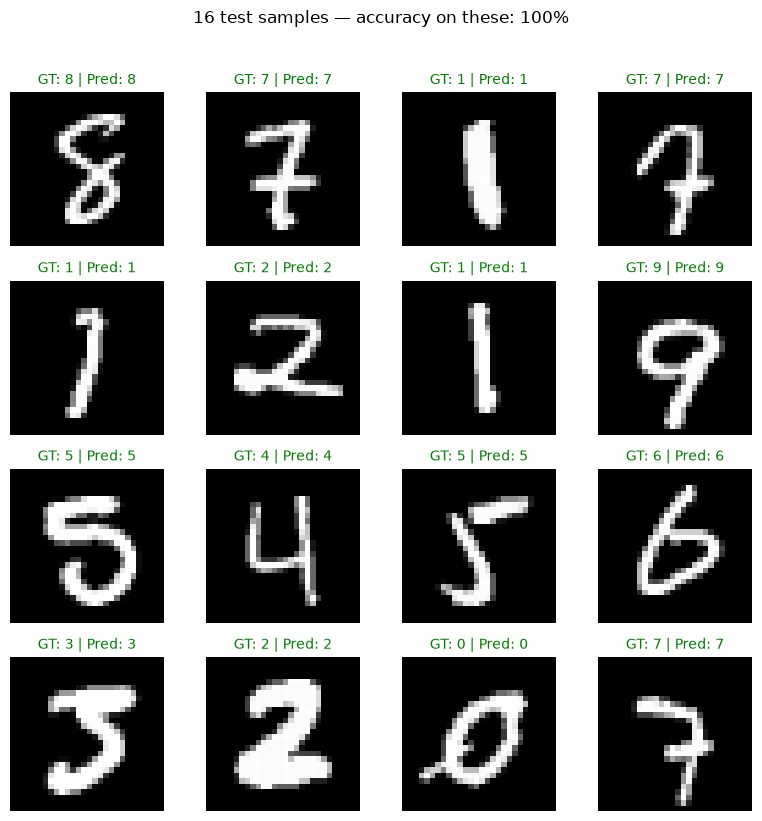

In [7]:
idx = np.random.choice(len(test_ds), 16, replace=False)  # seeded above
xs, ys = [], []
for i in idx:
    x, y = test_ds[i]
    xs.append(x)
    ys.append(y)
xs = torch.stack(xs).to(device)
ys = np.array(ys)

with torch.no_grad():
    preds = model(xs).argmax(1).cpu().numpy()

fig, axes = plt.subplots(4, 4, figsize=(8, 8))
for ax, xi, gt, pr in zip(axes.ravel(), xs.cpu().numpy(), ys, preds):
    img = np.clip(xi[0] * STD + MEAN, 0, 1)  # de-normalize for display
    ax.imshow(img, cmap="gray")
    ax.set_title(f"GT: {gt} | Pred: {pr}",
                 color="green" if gt == pr else "red", fontsize=10)
    ax.axis("off")
fig.suptitle(f"16 test samples — accuracy on these: {(ys == preds).mean():.0%}", y=1.02)
plt.tight_layout()
plt.savefig("grid_16.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Results

- Model: 3× Conv2d(3×3) + 2× MaxPool2 + 1× Linear — **every op via einops/einsum**
- Training: 5 epochs, Adam lr=1e-3, batch 64, MNIST (60k train)
- **Test-set accuracy (10k samples): 0.9892 (9892/10000)**
- 16-sample 4×4 grid above (also saved as `grid_16.png`)